In [43]:
# !pip install fredapi

In [1]:
from fredapi import Fred
import yfinance as yf
import pandas_datareader.data as web

import pandas as pd
import numpy as np

import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# !pip install pingouin
import pingouin as pg
from statsmodels.tsa.stattools import acf

#### Import Stock Data

In [2]:
# add as many precious metals as possible

In [3]:
### Current Tickers ###
mineral_stocks = [
    'GC=F',  # Gold
    'HG=F',  # Copper
    'PA=F',  # Palladium
    'PL=F',  # Platinum
    'SI=F',  # Silver
]

growth_stocks = [
    "NVDA",  # NVIDIA Corporation
    "MRVL",  # Marvell Technology Inc.
    "FTNT",  # Fortinet Inc.
    "AMD",   # Advanced Micro Devices, Inc.
    "CRM",   # Salesforce Inc.
    "ADBE",  # Adobe Inc.
    "ZM",    # Zoom Video Communications Inc.
    "SHOP",  # Shopify Inc.
    "SNAP",  # Snap Inc.
    "NET",   # Cloudflare, Inc.
    "TWLO",  # Twilio Inc.
    "MDB",   # MongoDB, Inc.
    "RBLX",  # Roblox Corporation
    "SNOW",  # Snowflake Inc.
    "PINS",  # Pinterest Inc.
    "TTD",   # The Trade Desk
    "DOCU",  # DocuSign, Inc.
    'SLAB',  # Silicon Laboratories Inc.
]

value_stocks = [
    "AAPL",  # Apple Inc.
    "MSFT",  # Microsoft Corporation
    "INTC",  # Intel Corporation
    "IBM",   # International Business Machines Corporation
    "ORCL",  # Oracle Corporation
    "CSCO",  # Cisco Systems, Inc.
    "HPE",   # Hewlett Packard Enterprise Co.
    "QCOM",  # Qualcomm Incorporated
    "TXN",   # Texas Instruments Incorporated
    "AVGO",  # Broadcom Inc.
    "MU",    # Micron Technology Inc.
    "LRCX",  # Lam Research Corporation
    "STX",   # Seagate Technology Holdings PLC
    "WDC",   # Western Digital Corporation
    "ADI",   # Analog Devices, Inc.
    "AMAT",  # Applied Materials, Inc.
    "MSI",   # Motorola Solutions, Inc.
    "VZ",    # Verizon Communications Inc.
    "TMUS"   # T-Mobile US, Inc.
]

market_indices = [
    "^DJI",     # Dow Jones Industrial Average (United States)
    "^GSPC",    # S&P 500 (United States)
    "^IXIC",    # NASDAQ Composite (United States)
    "^N225",    # Nikkei 225 (Japan)
    "^FTSE",    # FTSE 100 (United Kingdom)
    "^GDAXI",   # DAX (Germany)
    "^FCHI",    # CAC 40 (France)
    "HSI",      # Hang Seng Index (Hong Kong)
    "000001.SS",# Shanghai Composite Index (China)
    "^BSESN",   # SENSEX (India)
    "^NSEI",    # Nifty 50 (India)
    "^KS11",    # KOSPI (South Korea)
    "^AORD",    # All Ordinaries (Australia)
    "^BVSP",    # Bovespa (Brazil)
    "^MERV",    # MERVAL (Argentina)
    "^TWII",    # TAIEX (Taiwan)
    "^STI",     # Straits Times Index (Singapore)
    "^JKSE",    # Jakarta Composite Index (Indonesia)
]


#### Download Financial Data

In [4]:
start_date = "2020-01-01"


### Download Mineral Data ###
minerals = yf.download(mineral_stocks,start=start_date)[["Close","Volume"]]
minerals = minerals.reset_index(names='Date')
minerals = minerals.dropna()
minerals.columns = [(x[1] +' '+ x[0]).strip() for x in minerals.columns.to_list()]

### Create time stamp columns ###
minerals['Year'] = minerals.Date.dt.year
minerals['Month'] = minerals.Date.dt.month
minerals['Month Name'] = minerals.Date.dt.month_name()
minerals['Day'] = minerals.Date.dt.day



## Download Closing Price of Growth and Value Stocks in One DataFrame ###
all_stocks = growth_stocks + value_stocks
stock_data = yf.download(all_stocks, start=start_date, progress=False)['Close']
stock_data.reset_index(names='Date',inplace=True)

## worldwide markets
worldwide_markets = yf.download(market_indices, start=start_date, progress=False)['Close']

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  5 of 5 completed


#### Download Federal Economic Data

In [5]:
### EFFECTIVE FEDERAL FUNDS RATE ###
api_key = '970cbbb9d211d4b85f4e294ac3ccb3ff'
fred = Fred(api_key=api_key)
effr = fred.get_series('EFFR',observation_start='2020-01-01')

effr = pd.DataFrame(effr, columns = ['EFFR']).dropna()
effr.reset_index(names='Date',inplace=True)


### U.S. Dollar Index (DXY) ###
dxy = yf.download("DX-Y.NYB", start="2020-01-01", interval="1d")
dxy.reset_index(inplace=True)
dxy['Date'] = pd.to_datetime(pd.to_datetime(dxy['Date']).dt.date)
dxy.columns = ['DXY ' + x[0]  if x[0] != 'Date' else x[0] for x in dxy.columns.to_list()]

[*********************100%***********************]  1 of 1 completed


### Examine Platinum

In [6]:
minerals_vol_returns = minerals.filter(regex='Date|Close').copy()

minerals_return_cols = [x.replace('Close','Returns') for x in minerals_vol_returns.columns if x != 'Date']
minerals_vol_returns[minerals_return_cols] = minerals_vol_returns.iloc[:,1:].pct_change()

minerals_vol_cols = [x.replace('Returns','Volatility') for x in minerals_return_cols]
minerals_vol_returns[minerals_vol_cols] = minerals_vol_returns.loc[:,minerals_return_cols].rolling(window=30,min_periods=1).std()

minerals_vol_returns.set_index('Date',inplace=True)

In [7]:
### EXTRACT PLATINUM ###
plat_df= minerals_vol_returns.filter(regex='PL=F').copy()

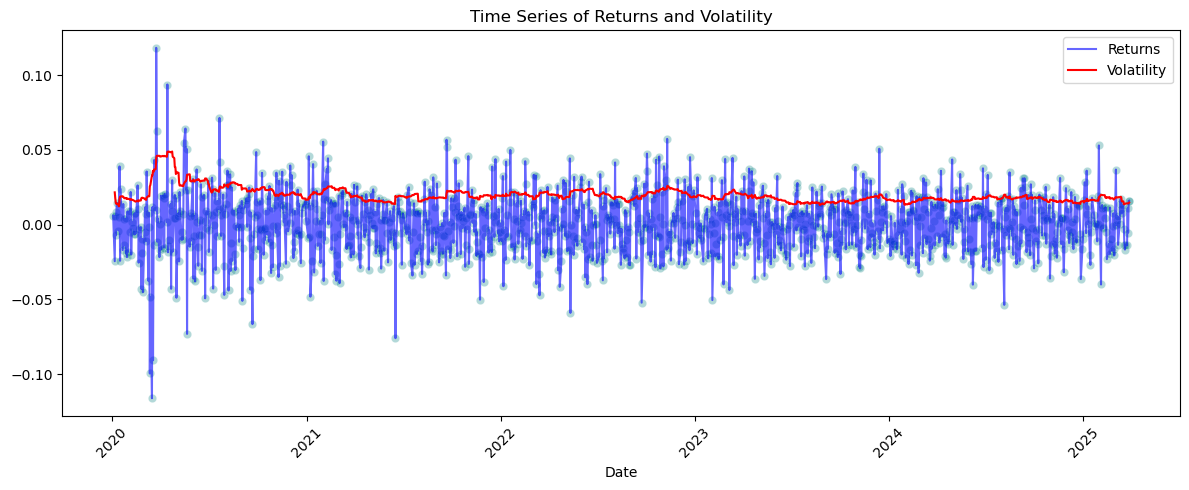

In [8]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Date', y='PL=F Returns', data=plat_df, label='Returns', color='blue',alpha=0.6)
sns.scatterplot(x='Date', y='PL=F Returns', data=plat_df, legend=False, color='teal',alpha=0.3)
sns.lineplot(x='Date', y='PL=F Volatility', data=plat_df, label='Volatility', color='red')


plt.xlabel('Date')
plt.ylabel('')
plt.title('Time Series of Returns and Volatility')
plt.legend()


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

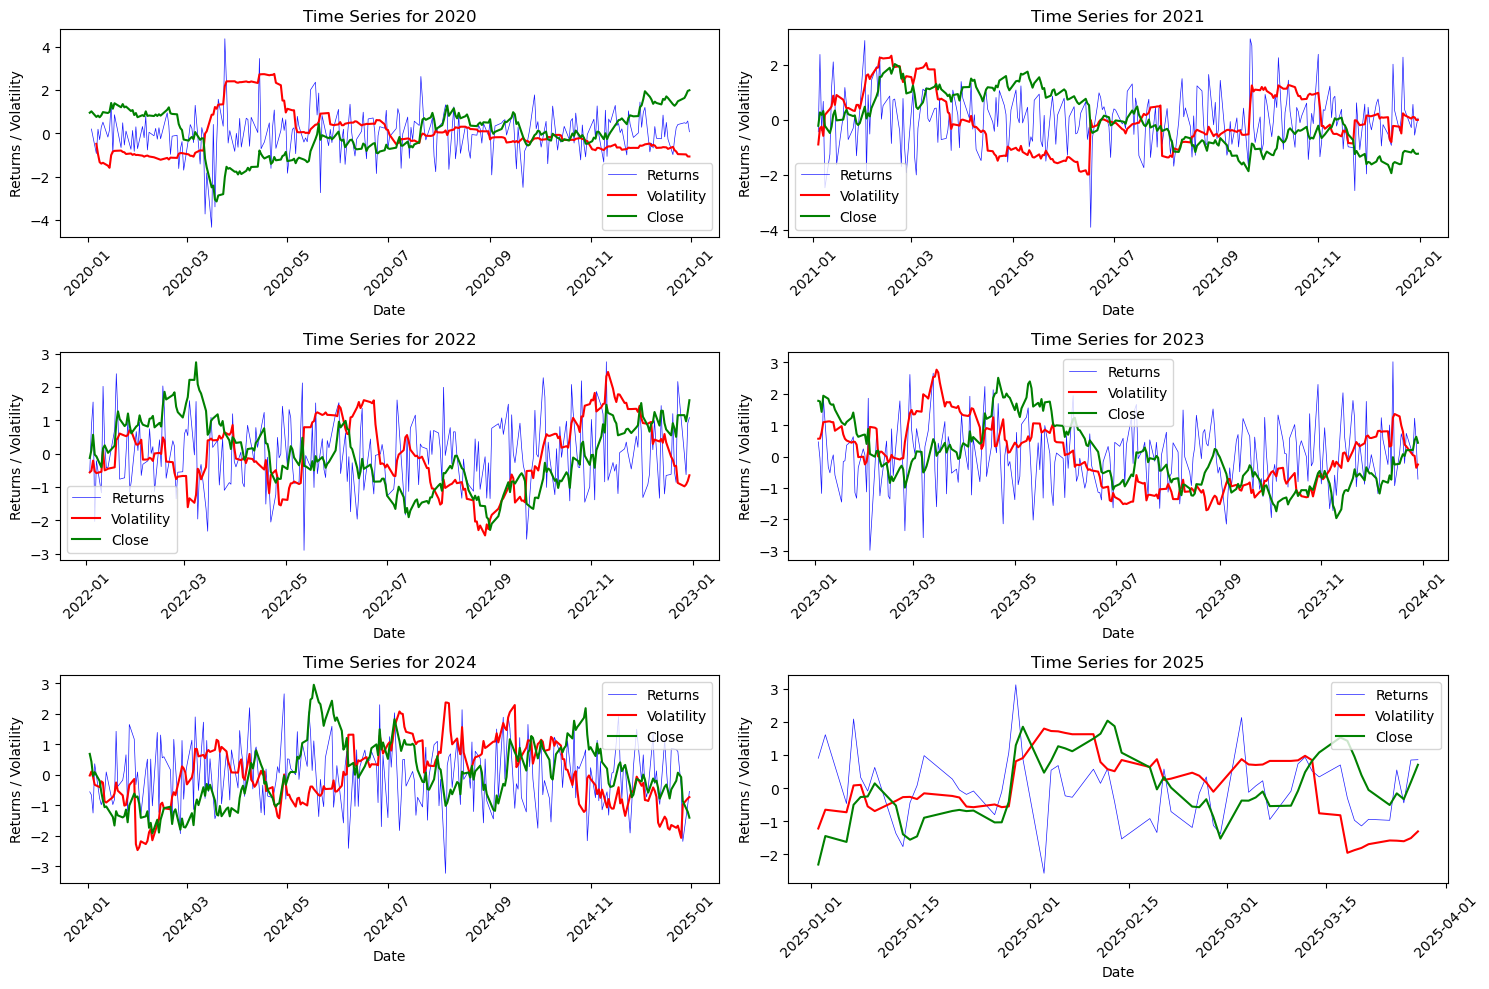

In [9]:
years = [2020, 2021, 2022, 2023, 2024, 2025]


plt.figure(figsize=(15, 10))


for i, year in enumerate(years):
   
    year_data = plat_df[plat_df.index.year == year]
    scaler = StandardScaler()
    year_data.loc[:,["scaled_close","scaled_volatility","scaled_returns"]] = scaler.fit_transform(year_data.loc[:,["PL=F Close","PL=F Volatility","PL=F Returns"]])
    
    
    ax1 = plt.subplot(3, 2, i+1) 
    
    sns.lineplot(x='Date', y='scaled_returns', data=year_data, label='Returns', color='blue', ax=ax1,alpha=0.9, linewidth=0.5)
    sns.lineplot(x='Date', y='scaled_volatility', data=year_data, label='Volatility', color='red', ax=ax1)
    sns.lineplot(x='Date', y='scaled_close', data=year_data, label='Close', color='green', ax=ax1)
    
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Returns / Volatility')
    ax1.set_title(f'Time Series for {year}')
    ax1.legend(loc='best')
    ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

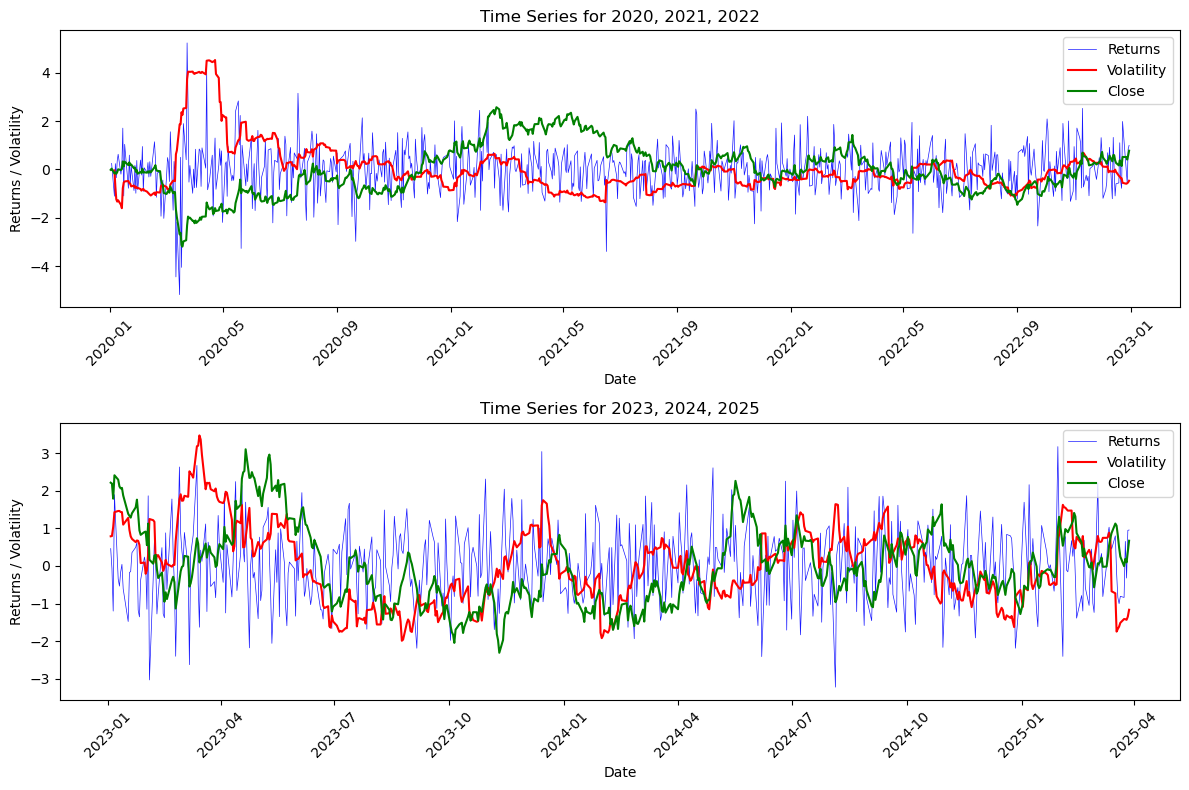

In [10]:
# Create a figure with subplots (2 rows, 1 column)
plt.figure(figsize=(15, 10))

# List of years for each plot
years_1 = [2020, 2021, 2022]
years_2 = [2023, 2024, 2025]

years = [years_1,years_2]


plt.figure(figsize=(12, 8))
for i, year in enumerate(years):
   
    year_data = plat_df[plat_df.index.year.isin(year)]
    scaler = StandardScaler()
    year_data.loc[:,["scaled_close","scaled_volatility","scaled_returns"]] = scaler.fit_transform(year_data.loc[:,["PL=F Close","PL=F Volatility","PL=F Returns"]])
    
    
    ax1 = plt.subplot(2, 1, i+1) 
    
    sns.lineplot(x='Date', y='scaled_returns', data=year_data, label='Returns', color='blue', ax=ax1,alpha=0.9, linewidth=0.5)
    sns.lineplot(x='Date', y='scaled_volatility', data=year_data, label='Volatility', color='red', ax=ax1)
    sns.lineplot(x='Date', y='scaled_close', data=year_data, label='Close', color='green', ax=ax1)
    
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Returns / Volatility')
    ax1.set_title(f'Time Series for {(', ').join([str(x) for x in year])}')
    ax1.legend(loc='best')
    ax1.tick_params(axis='x', rotation=45)


plt.tight_layout()


plt.show()


#### Examine Dollar index and Effective Federal Funds Rate

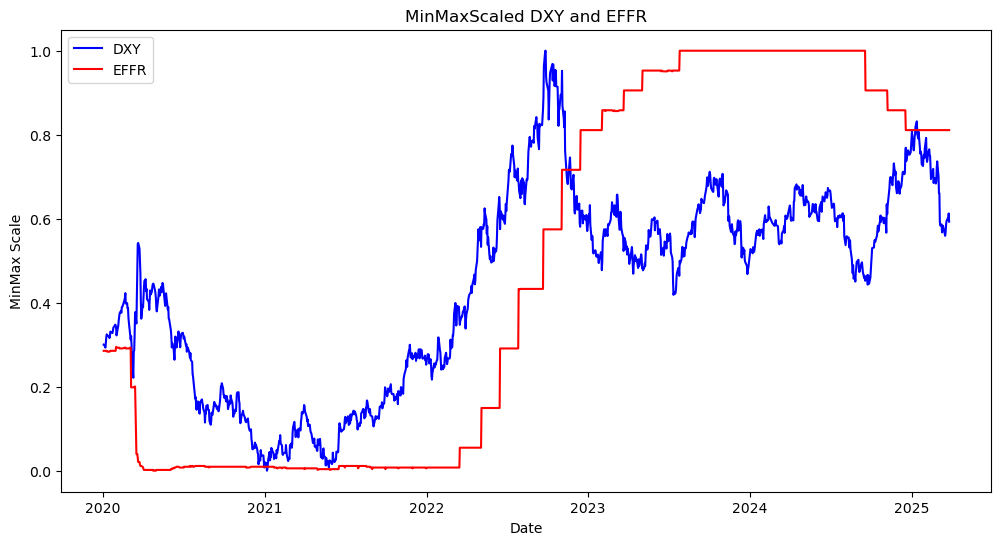

In [11]:
effr_dxy = effr.merge(dxy,on='Date',how='inner')

# scale values to visualize
scaler = MinMaxScaler()
effr_dxy.loc[:, ['dxy_scaled', 'effr_scaled']] = scaler.fit_transform(
    effr_dxy.loc[:, ['DXY Close', 'EFFR']]
)

plt.figure(figsize=(12, 6))


sns.lineplot(data=effr_dxy, x='Date', y='dxy_scaled', color='blue', label='DXY')
sns.lineplot(data=effr_dxy, x='Date', y='effr_scaled', color='red', label='EFFR')


plt.legend(loc='upper left')
plt.ylabel('MinMax Scale')
plt.title('MinMaxScaled DXY and EFFR')
plt.show()


In [12]:
## calculate log return from each closing price
minerals_log_return = minerals.filter(regex='Date|Close').copy()
minerals_log_return.iloc[:,1:] = np.log(minerals_log_return.iloc[:,1:].divide(minerals_log_return.iloc[:,1:].shift(1)))
minerals_log_return.columns = [x.replace(' Close','') + '_log_return' if x != 'Date' else x for x in minerals_log_return.columns.to_list()]

minerals_log_return.set_index('Date',inplace=True)

### Compare Standardized Mineral Prices to Mineral Prices Normalized by Price of First Date

#### Standardization Function:
#### $ z = \frac{(x - \mu)}{\sigma} $

#### Normalize by first price in dataset function:
#### $ z = \frac{Close Price}{First Close Price} $


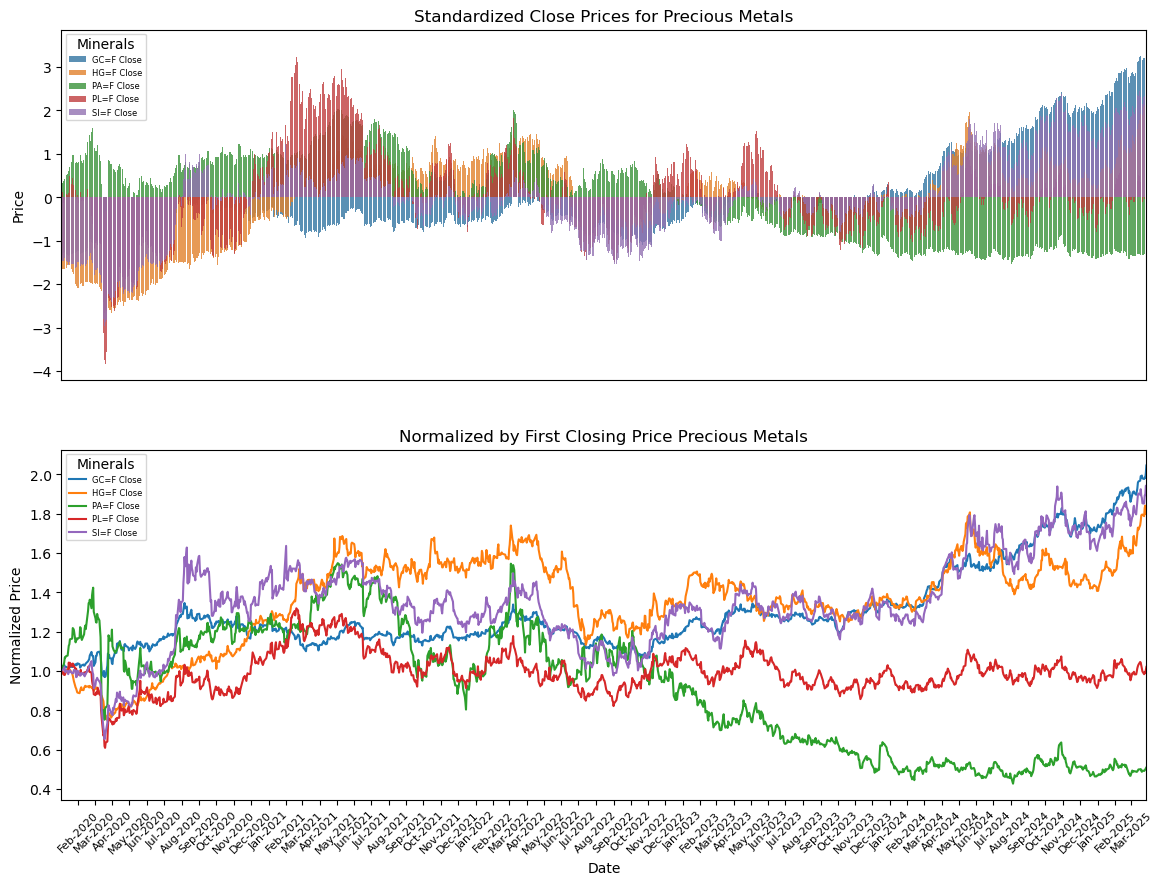

In [13]:
import matplotlib.dates as mdates

# Normalize the Close prices by dividing by the first value of each series
minerals_close = minerals[['Date','GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close', 'SI=F Close']].copy()

# Normalize each column by dividing by its first value
normalized_minerals = minerals_close.copy()
normalized_minerals.iloc[:,1:] = normalized_minerals.iloc[:,1:] / normalized_minerals.iloc[:,1:].iloc[0]
normalized_minerals_melt = pd.melt(normalized_minerals,id_vars=['Date'],var_name='Ticker',value_name='Normalized Close')

# Normalize Closing Prices

scaler = StandardScaler()
scaled_minerals_close = minerals_close.copy()
scaled_minerals_close.iloc[:,1:] = scaler.fit_transform(scaled_minerals_close.iloc[:,1:])
scaled_minerals_close_melt = pd.melt(scaled_minerals_close,id_vars=['Date'],var_name='Ticker',value_name='Close')


# Plotting the normalized Close prices
fig, axs = plt.subplots(2,1,figsize=(14, 10))

sns.barplot(data=scaled_minerals_close_melt,x='Date',y='Close',hue='Ticker',ax=axs[0],dodge=False,alpha=0.8)

sns.lineplot(data=normalized_minerals_melt,x='Date',y='Normalized Close',hue='Ticker',ax=axs[1])


# Adding title and labels
axs[0].set_title('Standardized Close Prices for Precious Metals', fontsize=12)
axs[0].set_xticklabels([])
axs[0].set_xticks([]) 
axs[0].set_xlabel('')
axs[0].set_ylabel('Price', fontsize=10)
axs[0].legend(title="Minerals", loc='upper left',fontsize=6)

# Adding title and labels
axs[1].set_title('Normalized by First Closing Price Precious Metals', fontsize=12)
axs[1].set_xlabel('Date', fontsize=10)
axs[1].set_ylabel('Normalized Price', fontsize=10)
axs[1].legend(title="Minerals",loc='upper left', fontsize=6)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  # Format as 'Jan-2025'
axs[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Show every 3rd month
axs[1].tick_params(axis='x', rotation=45, labelsize=8)  # Rotate labels
axs[1].set_xlim([normalized_minerals_melt['Date'].min(), normalized_minerals_melt['Date'].max()])



# Show the plot
plt.show()


## Percent Change at different Window Sizes
### analyze how past prices relate to current prices over different time horizons.

##### FUNCTION TO CREATE LAGGED DATAFRAMES 

In [14]:
def create_transformed_lagged_df(df, columns, lags, transform_func):
    """
    Create transformed lagged features for a DataFrame.
    Make sure unique date is the index
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with time series data.
        columns (list): List of column names to transform.
        lags (iterable): List or range of lags to apply.
        transform_func (function): Function to apply for lagging (e.g., shift, pct_change).
    
    Returns:
        pd.DataFrame: Transformed lagged features.
    """
    lagged_dfs = []
    for lag in lags:
        transformed_df = transform_func(df[columns], lag)
        transformed_df = transformed_df.add_suffix(f'_lag_{lag}')
        lagged_dfs.append(transformed_df)
    
    return pd.concat(lagged_dfs, axis=1)


##### FUNCTION TO CALCULATE CROSS CORRELATIONS ####

In [15]:

from itertools import combinations

def cross_correlations(df1, df2):
    """
    Compute cross-correlation for all columns in two dataframes.
    If df1 and df2 are the same, only unique column combinations are considered.

    Parameters:
        df1 (pd.DataFrame): First dataframe.
        df2 (pd.DataFrame): Second dataframe.

    Returns:
        Dictionary: Cross-correlation values for unique column combinations.
    """

    correlation_results = {}

    # If df1 and df2 are the same, use only unique column combinations
    if df1.equals(df2):
        column_pairs = combinations(df1.columns, 2)  
    else:
        column_pairs = [(col1, col2) for col1 in df1.columns for col2 in df2.columns]

    for col1, col2 in column_pairs:
        df1_series = df1[col1].dropna()
        df2_series = df2[col2].dropna()

        # Align by index
        aligned_data = pd.concat([df1_series, df2_series], axis=1).dropna()
        df1_series = aligned_data[col1]
        df2_series = aligned_data[col2]

        # Compute correlation
        cross_correlation = np.corrcoef(df1_series, df2_series)[0, 1].round(4)

        # Store results
        correlation_results[f'{col1} vs {col2}'] = cross_correlation

    return correlation_results


### Calculate Cross correlation between each mineral and the lag return of each mineral

In [71]:
lags = range(1,11)
mineral_tickers = ['GC=F Close', 'HG=F Close', 'PA=F Close', 'PL=F Close', 'SI=F Close']

lag_returns_df = create_transformed_lagged_df(
    minerals_vol_returns, 
    mineral_tickers, 
    lags, 
    lambda x, lag: x.pct_change(lag)
)

print(lag_returns_df.shape)
lag_returns_df.head(5)


(1318, 50)


,GC=F Close_lag_1,HG=F Close_lag_1,PA=F Close_lag_1,PL=F Close_lag_1,SI=F Close_lag_1,GC=F Close_lag_2,HG=F Close_lag_2,PA=F Close_lag_2,PL=F Close_lag_2,SI=F Close_lag_2,...,GC=F Close_lag_9,HG=F Close_lag_9,PA=F Close_lag_9,PL=F Close_lag_9,SI=F Close_lag_9,GC=F Close_lag_10,HG=F Close_lag_10,PA=F Close_lag_10,PL=F Close_lag_10,SI=F Close_lag_10
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,0.016202,-0.012178,0.014369,0.006029,0.005677,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,0.010973,0.000715,0.017336,-0.024479,0.001605,0.027353,-0.011472,0.031954,-0.018598,0.007292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,0.003576,0.001250,0.012416,0.005831,0.012101,0.014588,0.001965,0.029967,-0.018791,0.013726,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,-0.009161,0.005350,0.023385,-0.007246,-0.012448,-0.005619,0.006606,0.036091,-0.001458,-0.000497,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
lag_returns_df

,GC=F Close_lag_1,HG=F Close_lag_1,PA=F Close_lag_1,PL=F Close_lag_1,SI=F Close_lag_1,GC=F Close_lag_2,HG=F Close_lag_2,PA=F Close_lag_2,PL=F Close_lag_2,SI=F Close_lag_2,...,GC=F Close_lag_9,HG=F Close_lag_9,PA=F Close_lag_9,PL=F Close_lag_9,SI=F Close_lag_9,GC=F Close_lag_10,HG=F Close_lag_10,PA=F Close_lag_10,PL=F Close_lag_10,SI=F Close_lag_10
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,0.016202,-0.012178,0.014369,0.006029,0.005677,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,0.010973,0.000715,0.017336,-0.024479,0.001605,0.027353,-0.011472,0.031954,-0.018598,0.007292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,0.003576,0.001250,0.012416,0.005831,0.012101,0.014588,0.001965,0.029967,-0.018791,0.013726,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,-0.009161,0.005350,0.023385,-0.007246,-0.012448,-0.005619,0.006606,0.036091,-0.001458,-0.000497,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-24,-0.001690,-0.004619,-0.003680,-0.013932,-0.000751,-0.008849,-0.004130,0.009158,-0.027185,-0.015421,...,0.034399,0.068355,0.010126,-0.013123,0.011463,0.042235,0.091497,0.008406,0.000624,0.030674
2025-03-25,0.003518,0.023499,0.006437,0.010908,0.022155,0.001822,0.018771,0.002733,-0.003176,0.021388,...,0.028784,0.075088,0.011238,-0.019250,0.015470,0.038038,0.093460,0.016628,-0.002358,0.033872
2025-03-26,-0.000926,0.006367,0.009121,-0.005344,0.000912,0.002589,0.030016,0.015617,0.005506,0.023087,...,0.012264,0.064816,0.009969,-0.034514,-0.000529,0.027832,0.081933,0.020462,-0.024491,0.016396


In [17]:
# grab each mineral closing price
df1 = minerals.set_index('Date')[mineral_tickers]
# grab dataframe of lagged returns of each mineral
df2 = lag_returns_df


correlation_results = cross_correlations(df1, df2)
top_corr = sorted(correlation_results.items(), key=lambda x: abs(x[1]), reverse=True)[:20] #top 20 calculations
print('Top Correlations between Mineral Closing Price and Lagged Mineral Return')
for pair, corr in top_corr:
    print(f'{pair}: {corr:.2f}')


Top Correlations between Mineral Closing Price and Lagged Mineral Return
PL=F Close vs PL=F Close_lag_10: 0.26
PL=F Close vs PL=F Close_lag_9: 0.25
PL=F Close vs PL=F Close_lag_8: 0.24
PL=F Close vs PL=F Close_lag_7: 0.23
PL=F Close vs HG=F Close_lag_10: 0.22
PL=F Close vs PL=F Close_lag_6: 0.22
PL=F Close vs HG=F Close_lag_9: 0.21
GC=F Close vs GC=F Close_lag_10: 0.21
PL=F Close vs HG=F Close_lag_8: 0.21
PL=F Close vs PL=F Close_lag_5: 0.20
PL=F Close vs HG=F Close_lag_7: 0.20
GC=F Close vs GC=F Close_lag_9: 0.20
PL=F Close vs HG=F Close_lag_6: 0.19
GC=F Close vs GC=F Close_lag_8: 0.19
SI=F Close vs HG=F Close_lag_10: 0.18
PL=F Close vs PL=F Close_lag_4: 0.18
PL=F Close vs PA=F Close_lag_10: 0.18
PL=F Close vs HG=F Close_lag_5: 0.18
SI=F Close vs SI=F Close_lag_10: 0.18
GC=F Close vs GC=F Close_lag_7: 0.17


##### Correlation between each minearls Daily Returns

In [18]:

df1 = minerals_vol_returns.filter(like='Return')
df2 = minerals_vol_returns.filter(like='Return')
returns_cross_correlations = cross_correlations(df1,df2)

top_cross_correlations = sorted(returns_cross_correlations.items(), key=lambda x: x[1], reverse=True)[:]

print('Top Correlations between Mineral Return and Other Mineral Return')
for pair, corr in top_cross_correlations:
    print(f'{pair}: {corr:.2f}')

Top Correlations between Mineral Return and Other Mineral Return
GC=F Returns vs SI=F Returns: 0.78
PL=F Returns vs SI=F Returns: 0.64
PA=F Returns vs PL=F Returns: 0.58
GC=F Returns vs PL=F Returns: 0.54
PA=F Returns vs SI=F Returns: 0.46
HG=F Returns vs PL=F Returns: 0.46
HG=F Returns vs SI=F Returns: 0.41
GC=F Returns vs PA=F Returns: 0.39
HG=F Returns vs PA=F Returns: 0.38
GC=F Returns vs HG=F Returns: 0.30


##### Correlation between each minearls Lagged Daily Returns

In [19]:
import re
df1 = lag_returns_df
df2 = lag_returns_df

lagged_cross_correlations = cross_correlations(df1,df2)

# only looking at different tickers that are not the same lag - can adjust
filtered_lagged_cross_corr = {
    key: value
    for key, value in lagged_cross_correlations.items()
    if (match := re.findall(r'([\w=]+) Close_lag_(\d+)', key)) and 
       match[0][0] != match[1][0] and  
       int(match[0][1]) != int(match[1][1])  
}
top_lagged_cross_correlations = sorted(filtered_lagged_cross_corr.items(), key=lambda x: x[1], reverse=True)[:20]

print('Top Correlations between Lagged Mineral Return and Lagged Mineral Return')
for pair, corr in top_lagged_cross_correlations:
    print(f'{pair}: {corr:.2f}')

Top Correlations between Lagged Mineral Return and Lagged Mineral Return
SI=F Close_lag_7 vs GC=F Close_lag_8: 0.74
SI=F Close_lag_6 vs GC=F Close_lag_7: 0.74
SI=F Close_lag_8 vs GC=F Close_lag_9: 0.74
SI=F Close_lag_9 vs GC=F Close_lag_10: 0.73
SI=F Close_lag_5 vs GC=F Close_lag_6: 0.73
GC=F Close_lag_9 vs SI=F Close_lag_10: 0.73
GC=F Close_lag_5 vs SI=F Close_lag_6: 0.73
GC=F Close_lag_8 vs SI=F Close_lag_9: 0.73
GC=F Close_lag_6 vs SI=F Close_lag_7: 0.72
GC=F Close_lag_7 vs SI=F Close_lag_8: 0.72
GC=F Close_lag_4 vs SI=F Close_lag_5: 0.72
SI=F Close_lag_4 vs GC=F Close_lag_5: 0.72
SI=F Close_lag_3 vs GC=F Close_lag_4: 0.70
SI=F Close_lag_7 vs GC=F Close_lag_9: 0.69
SI=F Close_lag_6 vs GC=F Close_lag_8: 0.69
SI=F Close_lag_8 vs GC=F Close_lag_10: 0.69
GC=F Close_lag_3 vs SI=F Close_lag_4: 0.68
GC=F Close_lag_8 vs SI=F Close_lag_10: 0.68
SI=F Close_lag_9 vs PL=F Close_lag_10: 0.68
SI=F Close_lag_5 vs GC=F Close_lag_7: 0.68


### All stocks log returns

In [20]:
## calculate log return from each closing price
stock_data_log_return = stock_data.copy()
stock_data_log_return.iloc[:,1:] = np.log(stock_data_log_return.iloc[:,1:].divide(stock_data_log_return.iloc[:,1:].shift(1)))
stock_data_log_return.columns = [x+'_log_return' if x != 'Date' else x for x in stock_data_log_return.columns.to_list()]

stock_data_log_return.set_index('Date',inplace=True)

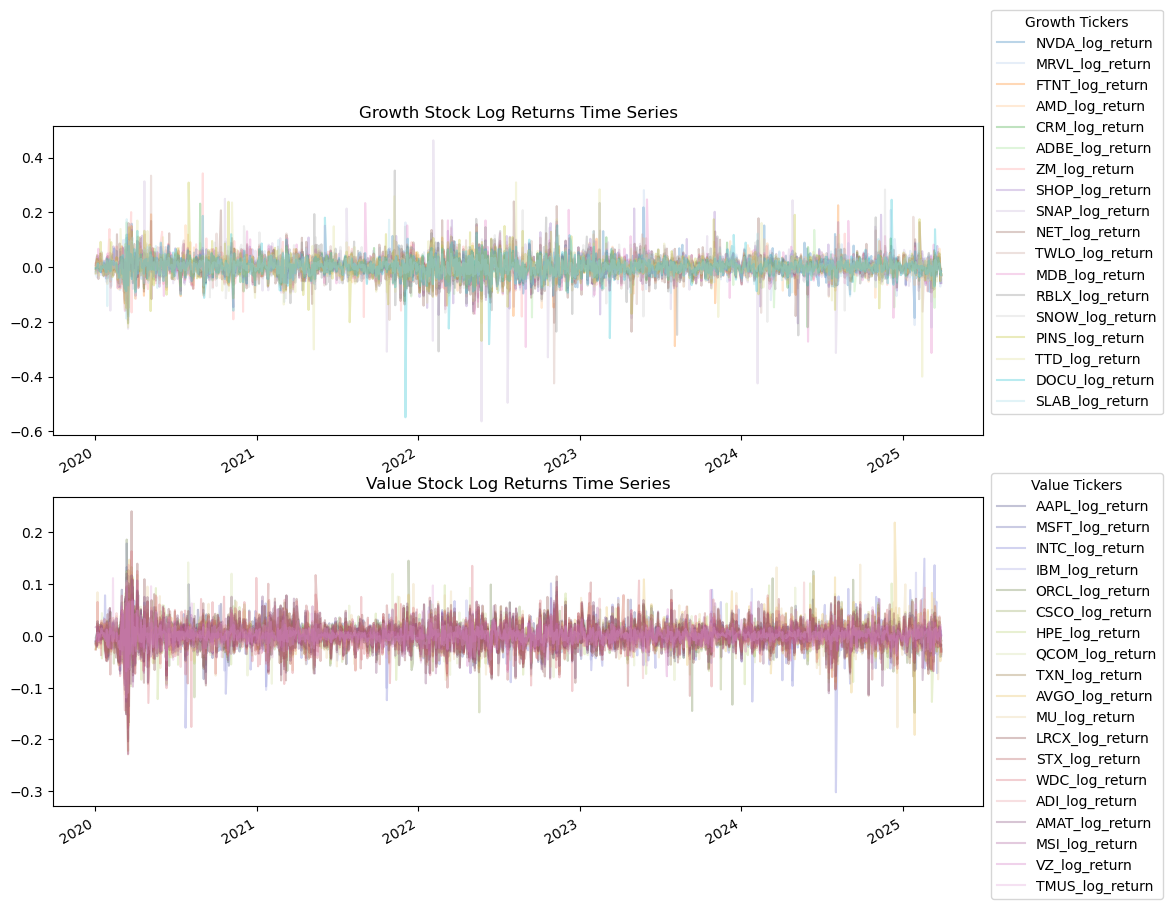

In [21]:
# Plotting the time series for each stock ticker (log returns) in the stock_returns_df

fig,axs = plt.subplots(2,1,figsize=(12,10))

stock_data_log_return.loc[:,[col+"_log_return" for col in growth_stocks]].plot(cmap='tab20',ax=axs[0],alpha=0.3)

stock_data_log_return.loc[:,[col+"_log_return" for col in value_stocks]].plot(cmap='tab20b',ax=axs[1],alpha=0.3)

axs[0].set_title('Growth Stock Log Returns Time Series')
axs[0].legend(title='Growth Tickers',loc='upper right', bbox_to_anchor=(1.2, 1.4))
axs[0].set_xlabel('')

axs[1].set_title('Value Stock Log Returns Time Series')
axs[1].legend(title='Value Tickers',loc='upper right', bbox_to_anchor=(1.2, 1.1))
axs[1].set_xlabel('')


plt.show()

### Lists of different column types
1. Mineral Log Return
2. Mineral Volatility
3. Stock Log Return
4. Stock Volatility

In [22]:
# List of columns for the different groups
minerals_log_return_columns = minerals_log_return.columns.to_list()[1:]
minerals_volatility_columns = minerals_vol_returns.filter(like='Vol').columns.to_list()
stock_log_return_columns = stock_data_log_return.columns.to_list()[1:]
minerals_close_columns = minerals_close.columns[1:].to_list()


### Examine Log Return Trends

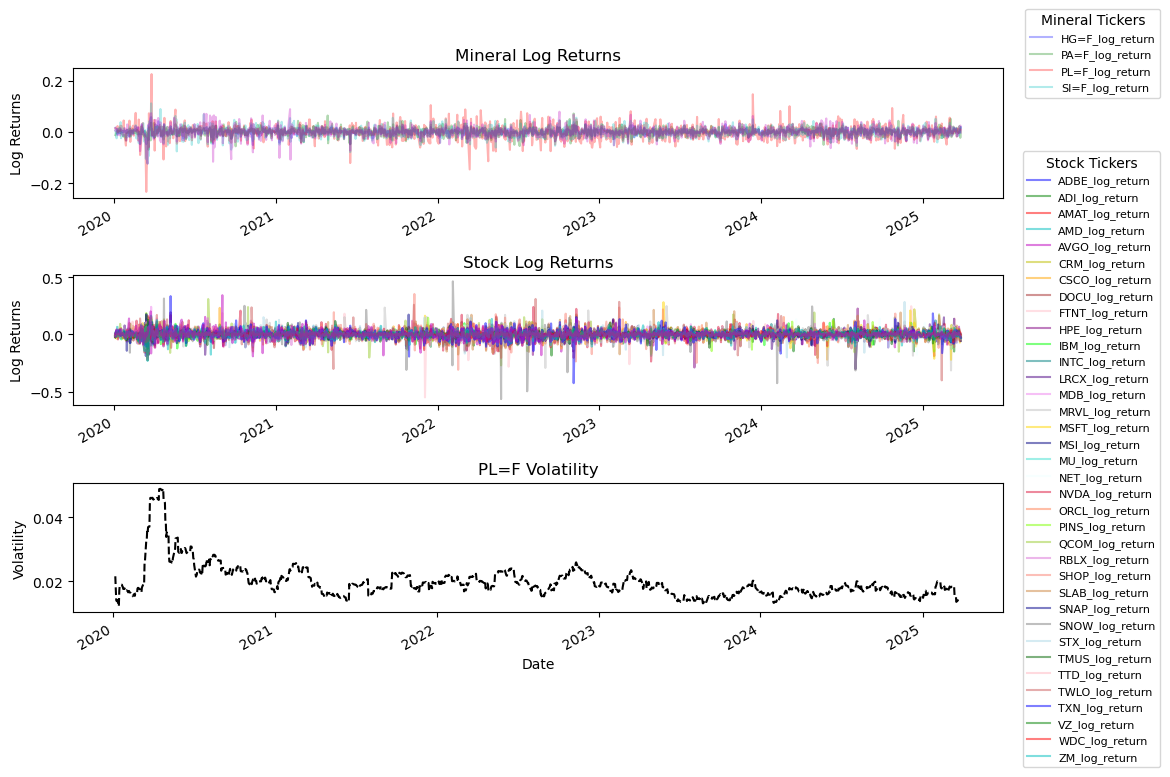

In [23]:
volatility_column = 'PL=F Volatility'

# Plotting the time series for minerals, stocks, and volatility
plt.figure(figsize=(14, 10))

# Plot mineral returns
plt.subplot(3, 1, 1)
minerals_log_return.plot(figsize=(12, 8), ax=plt.gca(), title="Mineral Log Returns",alpha=0.3, color=['b', 'g', 'r', 'c', 'm', 'y'])
plt.legend(minerals_log_return_columns,title='Mineral Tickers', loc='upper right', bbox_to_anchor=(1.175, 1.5),fontsize=8)
plt.ylabel('Log Returns')
plt.xlabel('')

# Plot stock returns
plt.subplot(3, 1, 2)
stock_data_log_return.plot(figsize=(12, 8), ax=plt.gca(),legend=False,alpha=0.5, title="Stock Log Returns",
                               color=['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'brown', 'pink', 'purple', 'lime', 'teal', 'indigo', 'violet',
                                      'silver', 'gold', 'navy', 'turquoise', 'azure', 'crimson', 'coral', 'chartreuse', 'yellowgreen', 'orchid',
                                      'salmon', 'peru', 'darkblue', 'gray', 'lightblue', 'darkgreen', 'lightpink', 'indianred'])
plt.legend(stock_log_return_columns,title='Stock Tickers', loc='upper right', bbox_to_anchor=(1.175, 2),fontsize=8)
plt.ylabel('Log Returns')
plt.xlabel('')

# Plot volatility
plt.subplot(3, 1, 3)
minerals_vol_returns[volatility_column].plot(figsize=(12, 8), ax=plt.gca(), title="PL=F Volatility", color='black', linestyle='--')
plt.ylabel('Volatility')

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.6)

plt.show()


### Examine Log Return Trends from Different Time Periods

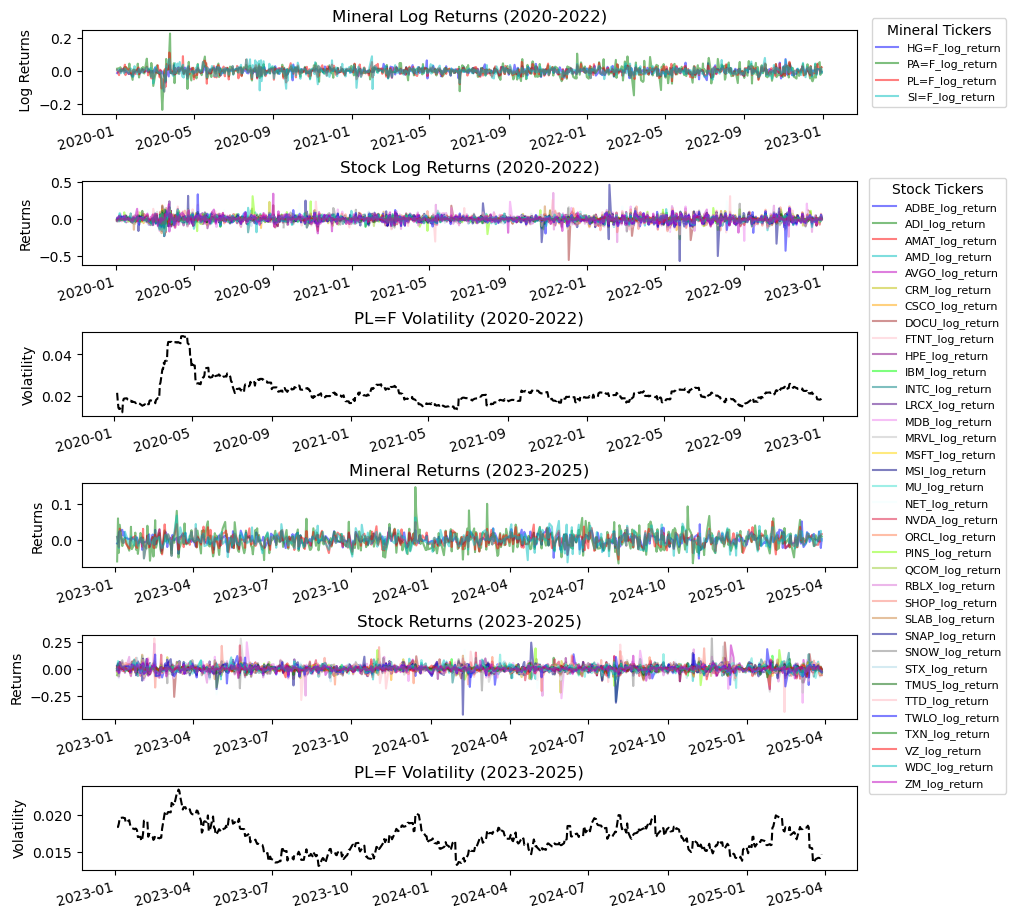

In [24]:

# Define the date ranges
start_date_1 = '2020-01-01'
end_date_1 = '2022-12-31'
start_date_2 = '2023-01-01'
end_date_2 = '2025-12-31'

# Filter data for the two periods
minerals_df_2020_2022 = minerals_log_return.loc[start_date_1:end_date_1].copy()
minerals_df_2023_2025 = minerals_log_return.loc[start_date_2:end_date_2].copy()

stock_df_2020_2022 = stock_data_log_return.loc[start_date_1:end_date_1].copy()
stock_df_2023_2025 = stock_data_log_return.loc[start_date_2:end_date_2].copy()

volatility_df_2020_2022 = minerals_vol_returns.filter(regex='Vol').loc[start_date_1:end_date_1].copy()
volatility_df_2023_2025 = minerals_vol_returns.filter(regex='Vol').loc[start_date_2:end_date_2].copy()

volatility_column = "PL=F Volatility"

# Plotting the time series for minerals, stocks, and volatility for 2020-2022
colors=['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'brown', 'pink', 'purple', 'lime', 'teal', 'indigo', 'violet', 'silver', 'gold', 'navy', 'turquoise', 'azure', 'crimson', 'coral', 'chartreuse', 'yellowgreen', 'orchid', 'salmon', 'peru', 'darkblue', 'gray', 'lightblue', 'darkgreen', 'lightpink']

# fig, axs = plt.subplots()
# plt.figure(figsize=(18, 7))

# Plot mineral returns (2020-2022)
axs1 = plt.subplot(6, 1, 1)
minerals_df_2020_2022[minerals_log_return_columns].plot(figsize=(10, 7), ax=axs1, title="Mineral Log Returns (2020-2022)", color=['b', 'g', 'r', 'c', 'm'],alpha=0.5)
plt.legend(minerals_log_return_columns,title='Mineral Tickers', loc='upper right', bbox_to_anchor=(1.2, 1.2),fontsize=8)
plt.xlabel('')
plt.ylabel(' Log Returns')
axs1.tick_params(axis='x', rotation=15)


# Plot stock returns (2020-2022)
axs2 = plt.subplot(6, 1, 2)
stock_df_2020_2022 [stock_log_return_columns].plot(figsize=(10, 7), ax=axs2, title="Stock Log Returns (2020-2022)", color=colors,alpha=0.5)
plt.legend(stock_log_return_columns,title='Stock Tickers', loc='upper right', bbox_to_anchor=(1.2, 1.1),fontsize=8)
plt.xlabel('')
plt.ylabel('Returns')
axs2.tick_params(axis='x', rotation=15)

# Plot volatility (2020-2022)
axs3 = plt.subplot(6, 1, 3)
volatility_df_2020_2022[volatility_column].plot(figsize=(10, 7), ax=axs3, title="PL=F Volatility (2020-2022)", color='black', linestyle='--')
plt.xlabel('')
plt.ylabel('Volatility')
axs3.tick_params(axis='x', rotation=15)

# Plotting the time series for minerals, stocks, and volatility for 2023-2025
# Plot mineral returns (2023-2025)
axs4 = plt.subplot(6, 1, 4)
minerals_df_2023_2025[minerals_log_return_columns].plot(figsize=(10, 7), ax=axs4, title="Mineral Returns (2023-2025)", color=['b', 'g', 'r', 'c', 'm', 'y'],legend=False,alpha=0.5)
plt.xlabel('')
plt.ylabel('Returns')
axs4.tick_params(axis='x', rotation=15)

# Plot stock returns (2023-2025)
axs5 = plt.subplot(6, 1, 5)
stock_df_2023_2025[stock_log_return_columns].plot(figsize=(10, 7), ax=axs5, title="Stock Returns (2023-2025)",color=colors,legend=False,alpha=0.5)
plt.xlabel('')
plt.ylabel('Returns')
axs5.tick_params(axis='x', rotation=15)

# Plot volatility (2023-2025)
axs6=plt.subplot(6, 1, 6)
volatility_df_2023_2025[volatility_column].plot(figsize=(10, 7), ax=axs6, title="PL=F Volatility (2023-2025)", color='black', linestyle='--',legend=False)
plt.ylabel('Volatility')
plt.xlabel('')
axs6.tick_params(axis='x', rotation=15)

plt.subplots_adjust(left=None, right=None, 
                    top=1.7, bottom=.5, 
                    wspace=0.4, hspace=0.8)

plt.show()


In [25]:

# Create lagged columns for the minerals
lagged_minerals_df = create_transformed_lagged_df(minerals_log_return, minerals_log_return_columns, lags,lambda x, lag: x.shift(lag))
lagged_stock_df = create_transformed_lagged_df(stock_data_log_return, stock_log_return_columns, lags,lambda x, lag: x.shift(lag))

array(['ADBE', 'ADI', 'AMAT', 'AMD', 'AVGO', 'CRM', 'CSCO', 'DOCU',
       'FTNT', 'HPE', 'IBM', 'INTC', 'LRCX', 'MDB', 'MRVL', 'MSFT', 'MSI',
       'MU', 'NET', 'NVDA', 'ORCL', 'PINS', 'QCOM', 'RBLX', 'SHOP',
       'SLAB', 'SNAP', 'SNOW', 'STX', 'TMUS', 'TTD', 'TWLO', 'TXN', 'VZ',
       'WDC', 'ZM'], dtype='<U4')

In [170]:
stock_lag_min_corr = pd.concat([lagged_minerals_df.tail(21),stock_data.tail(21).set_index('Date').pct_change()],axis=1).corr()


mineral_ticker_names = ['GC=F', 'HG=F', 'PA=F', 'PL=F','SI=F'] 
chosen_stock_names = np.unique([x.split('_')[0] for x in lagged_stock_df.columns])

result= {}
for mineral in mineral_ticker_names:
    for stock in chosen_stock_names:
        highest_lag = stock_lag_min_corr.filter(like=mineral).loc[[stock],:].max().sort_values(ascending=False).index
        if len(highest_lag) > 0:
            highest_lag = highest_lag[0]
        corr_value = stock_lag_min_corr.filter(like=mineral).loc[[stock],:].max().sort_values(ascending=False).values[:].round(4)
        if len(corr_value) > 0:
            corr_value = corr_value[0]
        result[stock] = (highest_lag,corr_value)
top = pd.DataFrame(result).T.rename(columns={0:'mineral_lag',1:'corr'}).sort_values(by='corr',ascending=False)

result= {}
for mineral in mineral_ticker_names:
    for stock in chosen_stock_names:
        highest_lag = stock_lag_min_corr.filter(like=mineral).loc[[stock],:].max().sort_values(ascending=True).index
        if len(highest_lag) > 0:
            highest_lag = highest_lag[0]
        corr_value = stock_lag_min_corr.filter(like=mineral).loc[[stock],:].max().sort_values(ascending=True).values[:].round(4)
        if len(corr_value) > 0:
            corr_value = corr_value[0]
        result[stock] = (highest_lag,corr_value)

bottom = pd.DataFrame(result).T.rename(columns={0:'mineral_lag',1:'corr'}).sort_values(by='corr',ascending=True)

In [175]:
print(top.head(20))

                mineral_lag    corr
FTNT  SI=F_log_return_lag_9  0.6645
ORCL  SI=F_log_return_lag_7  0.6348
NET   SI=F_log_return_lag_9  0.5947
STX   SI=F_log_return_lag_7  0.5923
AVGO  SI=F_log_return_lag_4    0.58
SNOW  SI=F_log_return_lag_7  0.5658
TWLO  SI=F_log_return_lag_9  0.5585
HPE   SI=F_log_return_lag_9  0.5584
ZM    SI=F_log_return_lag_9  0.5353
ADI   SI=F_log_return_lag_7  0.5231
SLAB  SI=F_log_return_lag_2   0.523
PINS  SI=F_log_return_lag_7  0.5167
AMD   SI=F_log_return_lag_4  0.4956
MRVL  SI=F_log_return_lag_4  0.4911
VZ    SI=F_log_return_lag_2  0.4877
DOCU  SI=F_log_return_lag_9  0.4851
CRM   SI=F_log_return_lag_9   0.478
LRCX  SI=F_log_return_lag_7  0.4777
WDC   SI=F_log_return_lag_7  0.4626
CSCO  SI=F_log_return_lag_9  0.4618


In [176]:
# bottom.merge(top,left_index=True, right_index=True, how='inner')

print(bottom.head(20))


                 mineral_lag    corr
MRVL   SI=F_log_return_lag_3 -0.5193
LRCX   SI=F_log_return_lag_3 -0.5175
SNOW   SI=F_log_return_lag_3    -0.5
MU     SI=F_log_return_lag_3 -0.4491
NVDA   SI=F_log_return_lag_3 -0.4344
AMAT   SI=F_log_return_lag_3 -0.4244
QCOM   SI=F_log_return_lag_3 -0.4179
MSFT   SI=F_log_return_lag_3  -0.406
VZ     SI=F_log_return_lag_4 -0.3941
ORCL   SI=F_log_return_lag_3 -0.3898
MDB    SI=F_log_return_lag_1 -0.3877
IBM    SI=F_log_return_lag_5 -0.3852
CSCO   SI=F_log_return_lag_3 -0.3849
ADI    SI=F_log_return_lag_3 -0.3799
AMD    SI=F_log_return_lag_3 -0.3707
PINS   SI=F_log_return_lag_3   -0.37
DOCU  SI=F_log_return_lag_10 -0.3485
AVGO   SI=F_log_return_lag_8 -0.3449
NET    SI=F_log_return_lag_3 -0.3402
TXN    SI=F_log_return_lag_3 -0.3319


[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date', ylabel='PA=F'>

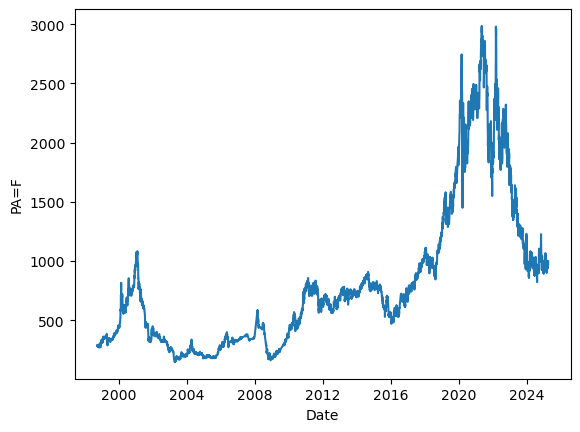

In [182]:
pal = yf.download('PA=F')['Close']

sns.lineplot(data=pal,y='PA=F',x=pal.index)

In [181]:
pal

Ticker,PA=F
Date,
1998-09-28,290.549988
1998-09-29,282.000000
1998-09-30,281.149994
1998-10-01,284.500000
1998-10-02,283.500000
...,...
2025-03-26,962.500000
2025-03-27,973.799988
2025-03-28,974.299988


In [26]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf, pacf, acf

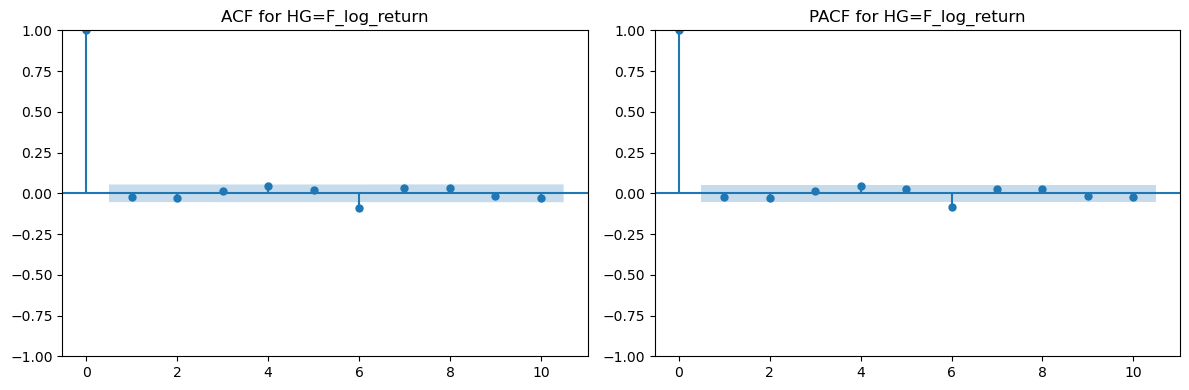

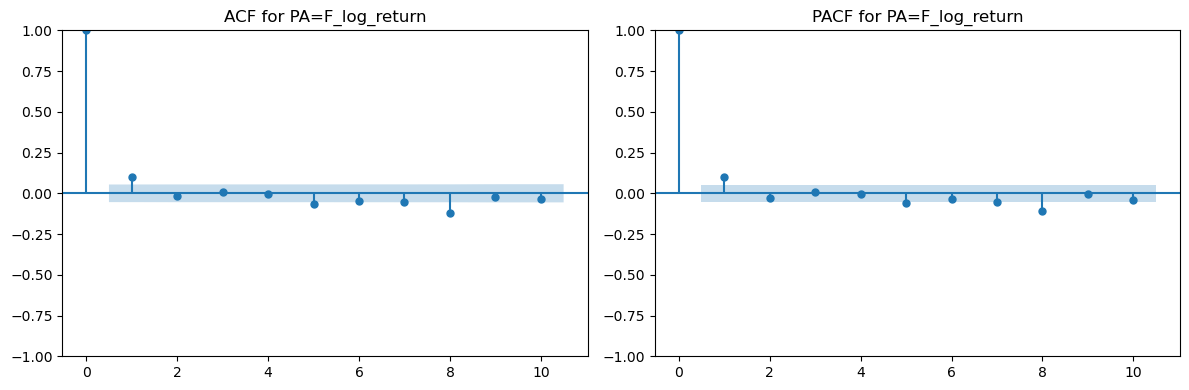

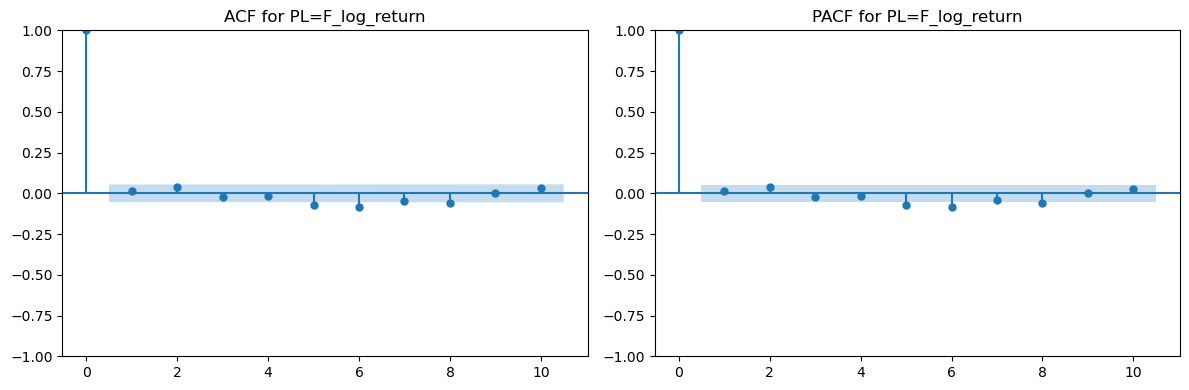

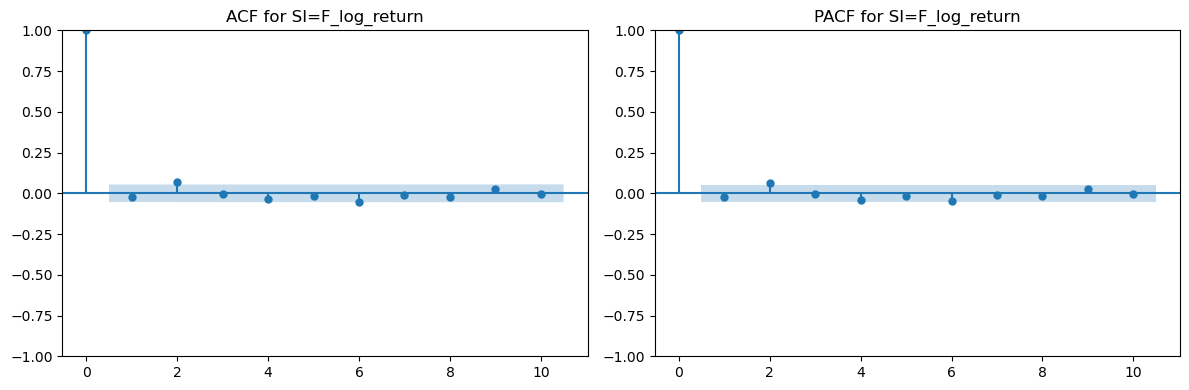

In [27]:
# Loop through each mineral column and plot ACF/PACF directly
for mineral in minerals_log_return_columns:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    sm.graphics.tsa.plot_acf(minerals_log_return[mineral].dropna(), lags=10, ax=axs[0])
    axs[0].set_title(f'ACF for {mineral}')
    
    sm.graphics.tsa.plot_pacf(minerals_log_return[mineral].dropna(), lags=10, ax=axs[1])
    axs[1].set_title(f'PACF for {mineral}')
    
    plt.tight_layout()
    plt.show()


### Top correlations between mineral lagged log returns and stock log Return

In [28]:
lag_log_mineral_log_stock_corr = cross_correlations(lagged_minerals_df,stock_data_log_return)
sorted(lag_log_mineral_log_stock_corr.items(), key=lambda x: abs(x[1]), reverse=True)[:20]

[('PL=F_log_return_lag_2 vs TMUS_log_return', 0.1352),
 ('PL=F_log_return_lag_2 vs PINS_log_return', 0.1113),
 ('PL=F_log_return_lag_4 vs FTNT_log_return', -0.1085),
 ('PL=F_log_return_lag_9 vs INTC_log_return', 0.1069),
 ('PL=F_log_return_lag_2 vs MSI_log_return', 0.1048),
 ('PL=F_log_return_lag_2 vs VZ_log_return', 0.1041),
 ('PL=F_log_return_lag_2 vs LRCX_log_return', 0.1007),
 ('PL=F_log_return_lag_2 vs AMD_log_return', 0.0954),
 ('PL=F_log_return_lag_2 vs SNAP_log_return', 0.0927),
 ('PL=F_log_return_lag_2 vs ADI_log_return', 0.0922),
 ('PL=F_log_return_lag_2 vs AMAT_log_return', 0.092),
 ('PL=F_log_return_lag_6 vs IBM_log_return', -0.0913),
 ('SI=F_log_return_lag_2 vs VZ_log_return', 0.0902),
 ('PA=F_log_return_lag_5 vs TTD_log_return', -0.0901),
 ('PL=F_log_return_lag_2 vs MSFT_log_return', 0.0899),
 ('HG=F_log_return_lag_1 vs PINS_log_return', -0.0897),
 ('SI=F_log_return_lag_6 vs LRCX_log_return', -0.0891),
 ('SI=F_log_return_lag_2 vs TMUS_log_return', 0.0889),
 ('PL=F_log_ret

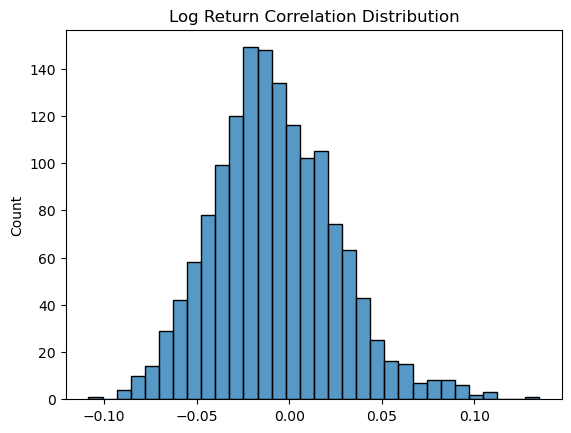

In [29]:
sns.histplot(list(lag_log_mineral_log_stock_corr.values()))
plt.title("Log Return Correlation Distribution")
plt.show()

### Top correlations between mineral lagged log returns and stock lagged log returns

In [30]:
mineral_stock_lag_corr = cross_correlations(lagged_minerals_df,lagged_stock_df)
top_mineral_stock_lag_corr = sorted(mineral_stock_lag_corr.items(), key=lambda x: abs(x[1]), reverse=True)[:20]

top_mineral_stock_lag_corr

[('HG=F_log_return_lag_9 vs WDC_log_return_lag_9', 0.2652),
 ('HG=F_log_return_lag_10 vs WDC_log_return_lag_10', 0.2652),
 ('HG=F_log_return_lag_7 vs WDC_log_return_lag_7', 0.2651),
 ('HG=F_log_return_lag_8 vs WDC_log_return_lag_8', 0.265),
 ('HG=F_log_return_lag_6 vs WDC_log_return_lag_6', 0.2649),
 ('HG=F_log_return_lag_5 vs WDC_log_return_lag_5', 0.2648),
 ('HG=F_log_return_lag_4 vs WDC_log_return_lag_4', 0.2639),
 ('HG=F_log_return_lag_1 vs WDC_log_return_lag_1', 0.2633),
 ('HG=F_log_return_lag_2 vs WDC_log_return_lag_2', 0.2626),
 ('HG=F_log_return_lag_3 vs WDC_log_return_lag_3', 0.2625),
 ('PL=F_log_return_lag_3 vs WDC_log_return_lag_3', 0.2542),
 ('PL=F_log_return_lag_5 vs ADI_log_return_lag_5', 0.254),
 ('PL=F_log_return_lag_5 vs WDC_log_return_lag_5', 0.254),
 ('PL=F_log_return_lag_3 vs ADI_log_return_lag_3', 0.2539),
 ('PL=F_log_return_lag_6 vs ADI_log_return_lag_6', 0.2538),
 ('PL=F_log_return_lag_6 vs WDC_log_return_lag_6', 0.2537),
 ('PL=F_log_return_lag_8 vs WDC_log_retur

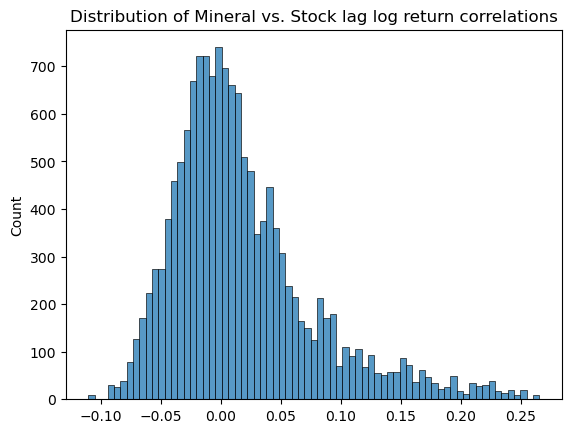

In [31]:
sns.histplot(list(mineral_stock_lag_corr.values()))
plt.title("Distribution of Mineral vs. Stock lag log return correlations")
plt.show()

#### Examine Volume and Volatility

In [ ]:
### Create Volume Dataframe
epsilon = 1e-8
mineral_volume = minerals.filter(regex='Date|Volume').set_index('Date').copy() + epsilon
# mineral_VolatilityOfVolume = mineral_volume.pct_change().rolling(window=30,min_periods=1).std()
mineral_VolatilityOfVolume = np.log(mineral_volume).diff().rolling(window=30, min_periods=1).std()

mineral_VolatilityOfClosingPrice = minerals_vol_returns.filter(regex='Volatility').copy()

mineral_vol = pd.concat([mineral_VolatilityOfVolume,mineral_VolatilityOfClosingPrice],axis=1).dropna()

scaler = StandardScaler()

min_vol_scaled = pd.DataFrame(scaler.fit_transform(mineral_vol),columns=mineral_vol.columns,index=mineral_vol.index)

In [65]:
log_returns_volume = np.log(mineral_volume).diff()
log_returns_price = np.log(minerals_close.set_index('Date')).diff()

volatility_volume = log_returns_volume.rolling(window=30, min_periods=1).std()
volatility_price = log_returns_price.rolling(window=30, min_periods=1).std()

vp_vv = pd.concat([volatility_volume,volatility_price],axis=1)

scaler = StandardScaler()

vp_vv_scaled = pd.DataFrame(scaler.fit_transform(vp_vv),columns=vp_vv.columns,index=vp_vv.index)


<Axes: >

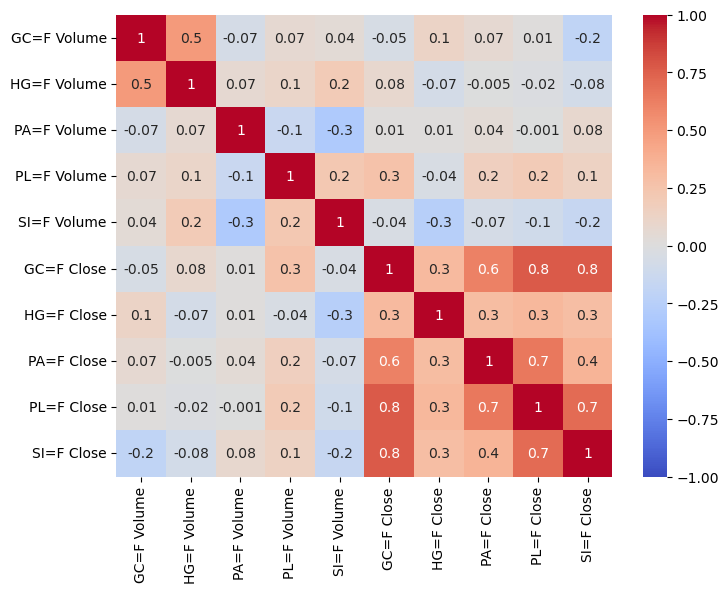

In [66]:
plt.figure(figsize=(8,6))
sns.heatmap(vp_vv.corr(),cmap='coolwarm',annot=True,fmt='.1g',vmin=-1,vmax=1)

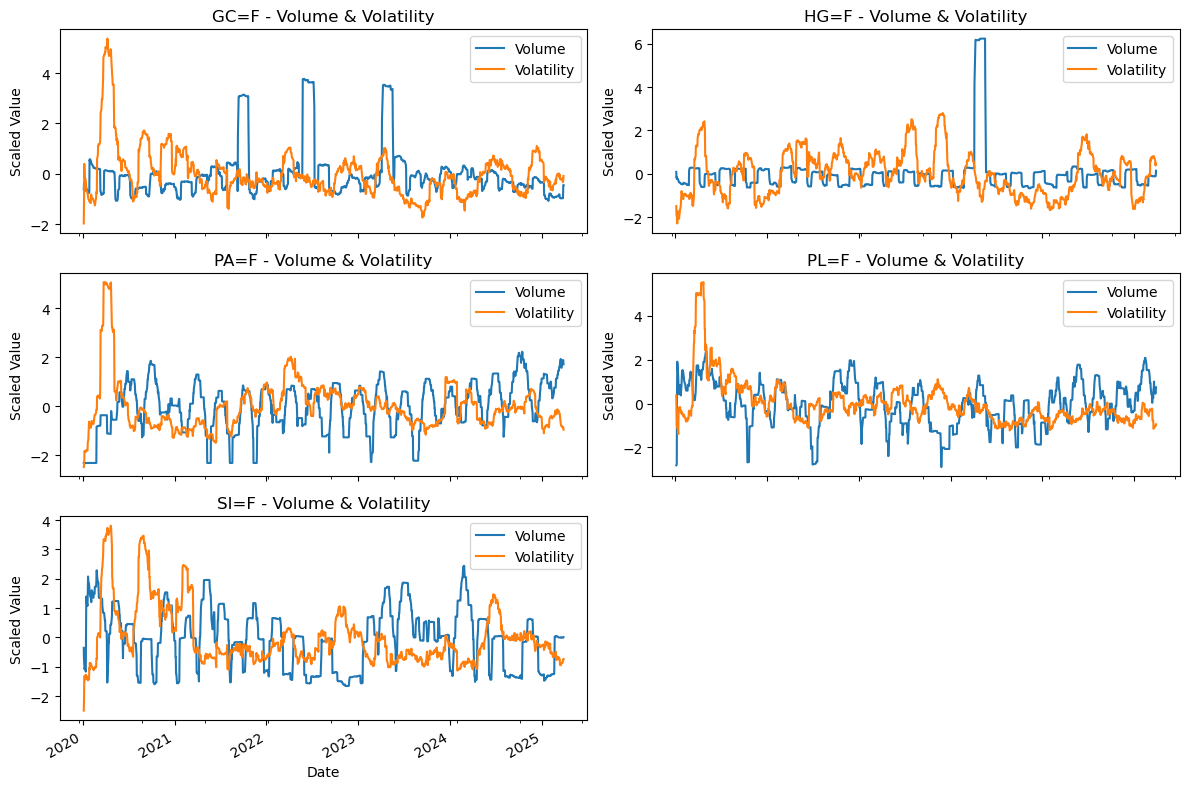

In [67]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

flat_axes = axes.ravel()  
mineral_names = ["GC=F", "HG=F", "PA=F", "PL=F", "SI=F"] 

for i, mineral in enumerate(mineral_names):
    ax = flat_axes[i]
    
    
    vol_col = f"{mineral} Volume"
    volat_col = f"{mineral} Close"
    
    vp_vv_scaled[[vol_col, volat_col]].plot(ax=ax)
    
    ax.set_title(f"{mineral} - Volume & Volatility")
    ax.set_ylabel("Scaled Value")
    ax.legend(["Volume", "Volatility"])

flat_axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


In [35]:
scaler = MinMaxScaler()
mineral_volume = pd.DataFrame(scaler.fit_transform(mineral_volume),columns=mineral_volume.columns,index=mineral_volume.index)

In [36]:
# Create lagged volume and volatility columns up to 5 lags
lags = range(1, 6)
lagged_volatility_columns = minerals_vol_returns.filter(like='Vola').columns
mineral_volume_columns =  mineral_volume.columns

# Create a DataFrame to hold lagged values
lagged_volume_df =  create_transformed_lagged_df(mineral_volume, mineral_volume_columns, lags,lambda x, lag: x.pct_change(lag))
lagged_volatility_df = create_transformed_lagged_df(minerals_vol_returns, lagged_volatility_columns, lags,lambda x, lag: x.shift(lag))

In [37]:
# Function to calculate ACF and PACF for a single series
def calculate_acf_pacf(x, lags=8):
    x_values = x.values.flatten() 
    lags = int(lags)
    
    # Calculate ACF and PACF using numpy arrays
    acf_vals = acf(x_values, nlags=lags, adjusted=True)  # Only use adjusted (no fft)
    pacf_vals = pacf(x_values, nlags=lags)  # Removed adjusted argument as it is not accepted now
    
    return acf_vals, pacf_vals

# Now calculate ACF and PACF for each interaction term with stock returns
acf_results = {}
pacf_results = {}


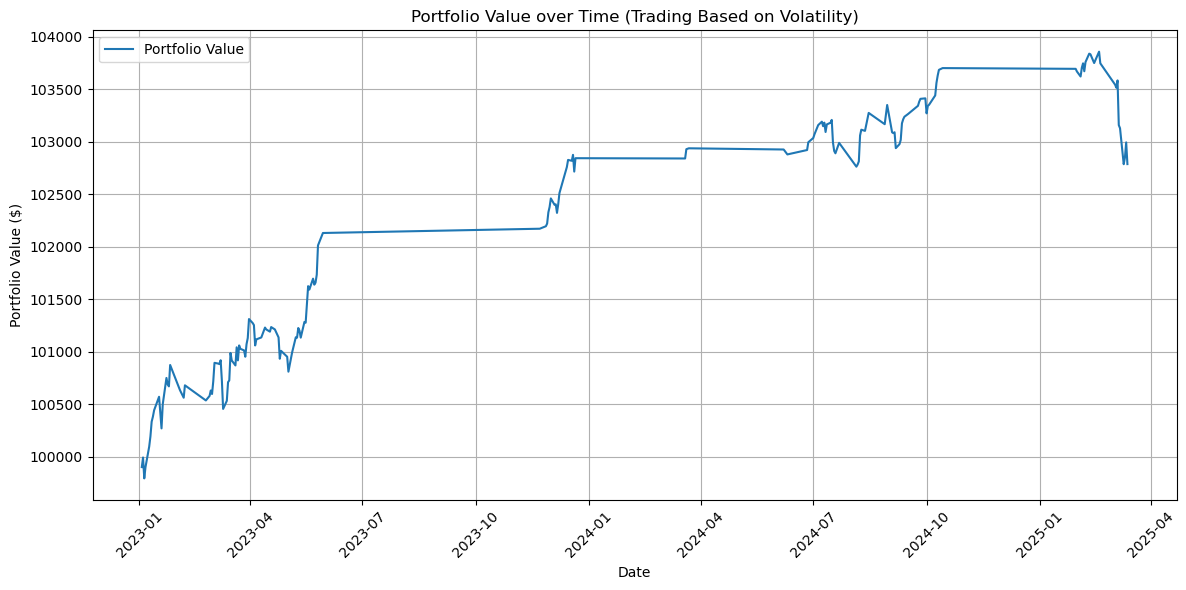

In [38]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.06  

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = pd.merge(stock_data_log_return[stock_data_log_return.index <= '2022-12-31'], minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')
test_data = pd.merge(stock_data_log_return[stock_data_log_return.index >= '2023-01-01'],minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns


max_investment = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Volatility']
    if np.isnan(volatility):
        continue
  
    if volatility < np.percentile(test_data['PL=F Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade
    total_investment = min(portfolio_value, max_investment_pct * portfolio_value)  # Ensure not exceeding total portfolio

    # Investment per stock (split the total investment evenly)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        if pd.isna(row[stock]):
            continue

        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Update portfolio based on the return for this stock (assuming buying)
        portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
        portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
        
        trade_history.append({
            'date': row.name,
            'action': 'Buy',
            'stock': stock,
            'investment': investment_per_stock,
            'portfolio_value': portfolio_value,
            'return_pct': stock_return * 100,
            'gain_loss': investment_per_stock * stock_return

        })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


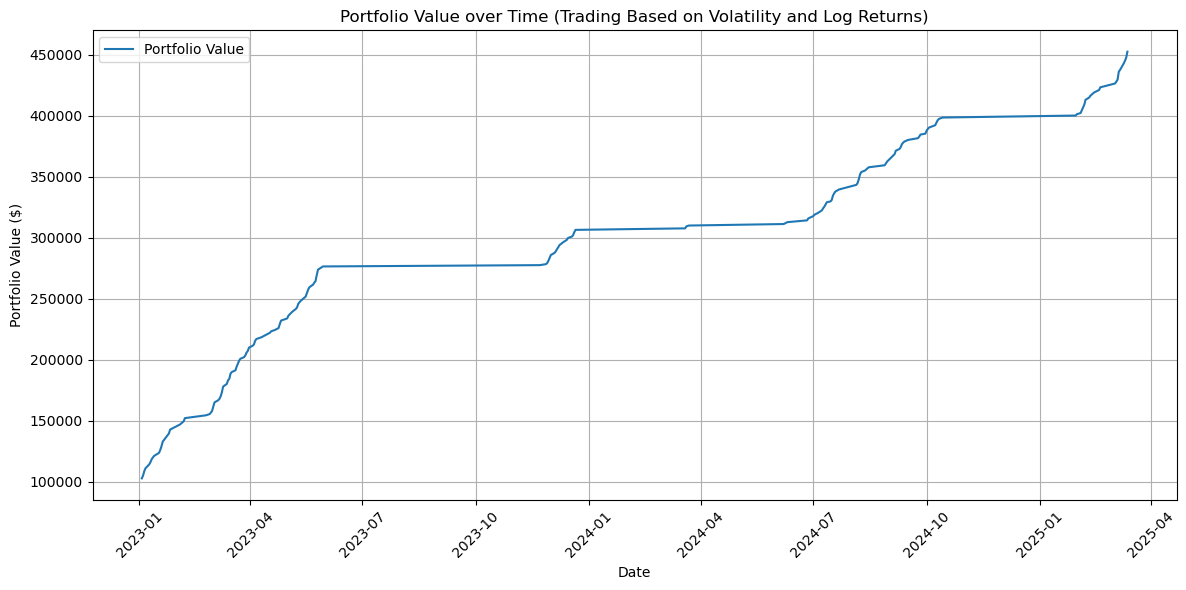

In [39]:

# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.06  # Max 6% of portfolio per stock

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = pd.merge(stock_data_log_return[stock_data_log_return.index <= '2022-12-31'], minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')
test_data = pd.merge(stock_data_log_return[stock_data_log_return.index >= '2023-01-01'],minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns


max_investment = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['PL=F Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade
    total_investment = min(portfolio_value, max_investment * len(stocks_to_buy))  # Ensure not exceeding total portfolio

    # Investment per stock (split the total investment evenly)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility and Log Returns)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


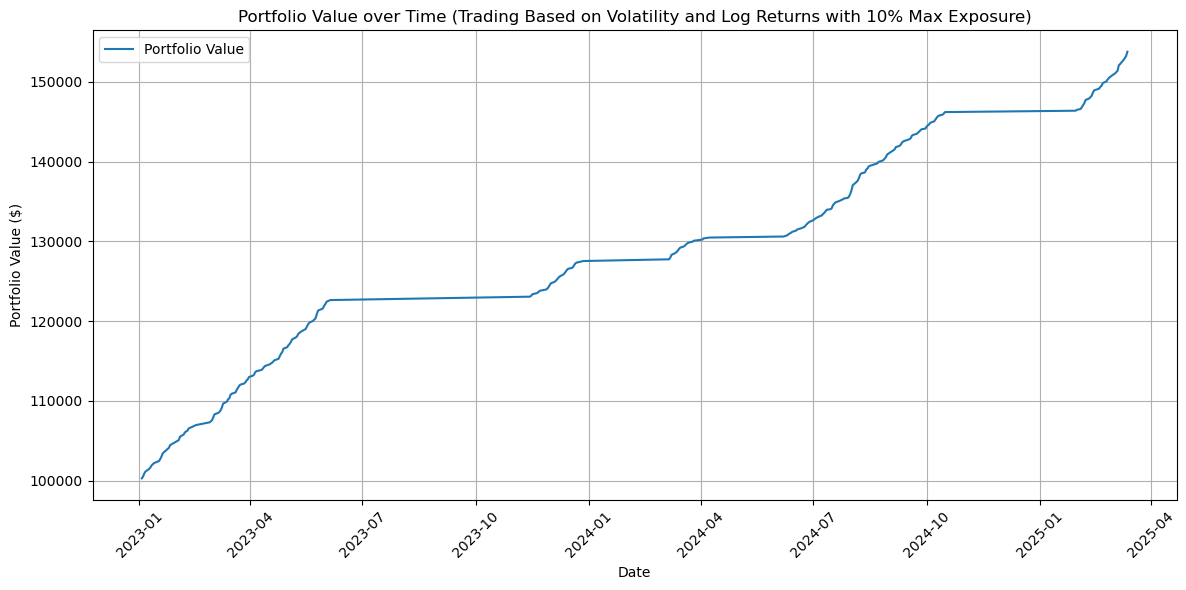

In [40]:


# Initialize parameters for the strategy
volatility_threshold_pct = 0.55  # Top 30% volatility for trading
max_investment_pct = 0.1  # Total max exposure per day is 10% of the portfolio

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = pd.merge(stock_data_log_return[stock_data_log_return.index <= '2022-12-31'], minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')
test_data = pd.merge(stock_data_log_return[stock_data_log_return.index >= '2023-01-01'],minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns

# Calculate max exposure per day (10% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['PL=F Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 10% of portfolio)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 10% daily exposure

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

# Plot the cumulative returns over time
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value over Time (Trading Based on Volatility and Log Returns with 10% Max Exposure)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.tight_layout()  # Adjust the layout to fit labels
plt.show()


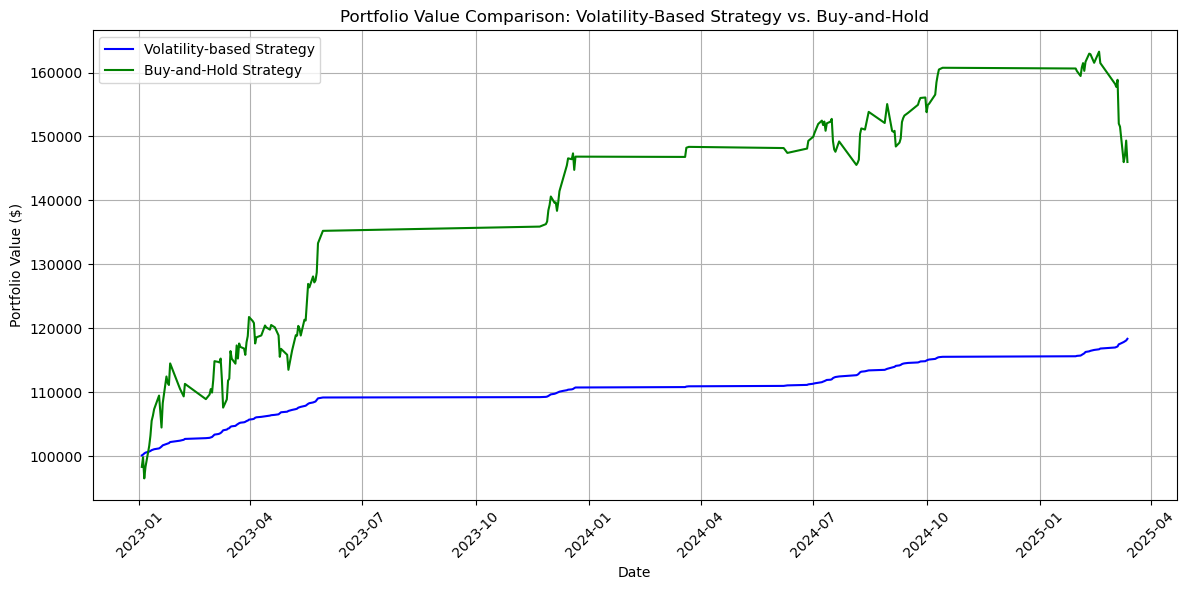

Volatility-Based Strategy Volatility: 0.0005
Buy-and-Hold Strategy Volatility: 0.0151
Volatility-Based Strategy Sharpe Ratio: 2.0305
Buy-and-Hold Strategy Sharpe Ratio: 0.1560


In [41]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.7  # Top 30% volatility for trading
max_investment_pct = 0.05  # Total max exposure per day is 10% of the portfolio

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = pd.merge(stock_data_log_return[stock_data_log_return.index <= '2022-12-31'], minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')
test_data = pd.merge(stock_data_log_return[stock_data_log_return.index >= '2023-01-01'],minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns
buy_and_hold_value = initial_balance
buy_and_hold_cumulative_returns = []  # Track buy and hold cumulative returns

# Calculate max exposure per day (10% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['PL=F Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 10% of portfolio)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 10% daily exposure

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

    # Buy-and-Hold Strategy (equally invest in each stock at the start and hold)
    buy_and_hold_investment_per_stock = initial_balance / len(stocks_to_buy)
    
    for stock in stocks_to_buy:
        stock_return = np.exp(row[stock]) - 1
        buy_and_hold_value += buy_and_hold_investment_per_stock * stock_return
    
    # Store the buy-and-hold portfolio value for comparison
    buy_and_hold_cumulative_returns.append(buy_and_hold_value)

# Convert portfolio date for proper alignment
portfolio_dates = pd.to_datetime(portfolio_dates)

# Calculate the cumulative returns for both strategies
cumulative_returns = np.array(cumulative_returns)
buy_and_hold_cumulative_returns = np.array(buy_and_hold_cumulative_returns)

# Plot the cumulative returns of both strategies
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Volatility-based Strategy", color="blue")
plt.plot(portfolio_dates, buy_and_hold_cumulative_returns, label="Buy-and-Hold Strategy", color="green")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value Comparison: Volatility-Based Strategy vs. Buy-and-Hold")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate volatility for both strategies
volatility_volatility_based = np.std(np.diff(np.log(cumulative_returns)))
volatility_buy_and_hold = np.std(np.diff(np.log(buy_and_hold_cumulative_returns)))

# Calculate Sharpe Ratios (assume risk-free rate of 0)
mean_return_volatility_based = np.mean(np.diff(np.log(cumulative_returns)))
mean_return_buy_and_hold = np.mean(np.diff(np.log(buy_and_hold_cumulative_returns)))

sharpe_ratio_volatility_based = mean_return_volatility_based / volatility_volatility_based
sharpe_ratio_buy_and_hold = mean_return_buy_and_hold / volatility_buy_and_hold

print(f"Volatility-Based Strategy Volatility: {volatility_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Volatility: {volatility_buy_and_hold:.4f}")
print(f"Volatility-Based Strategy Sharpe Ratio: {sharpe_ratio_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Sharpe Ratio: {sharpe_ratio_buy_and_hold:.4f}")


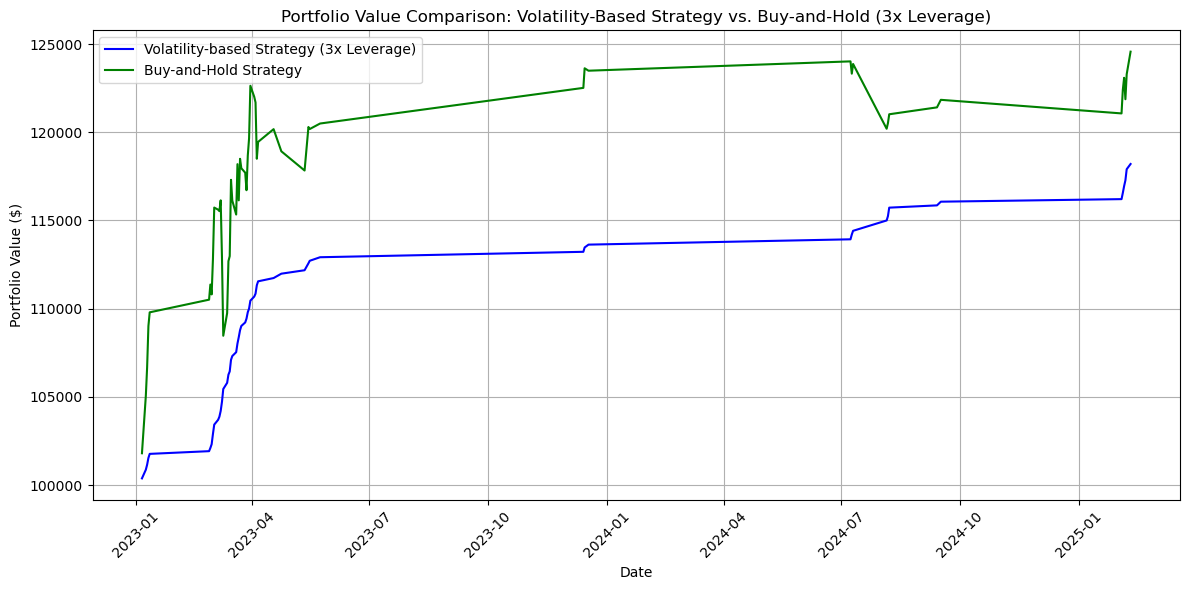

Volatility-Based Strategy Volatility (3x Leverage): 0.0014
Buy-and-Hold Strategy Volatility: 0.0151
Volatility-Based Strategy Sharpe Ratio (3x Leverage): 2.1226
Buy-and-Hold Strategy Sharpe Ratio: 0.2394


In [42]:
# Initialize parameters for the strategy
volatility_threshold_pct = 0.9  # Top 30% volatility for trading
max_investment_pct = 0.05  # Total max exposure per day is 5% of the portfolio
leverage_factor = 3  # 3x leverage

# Define the stocks involved in the strategy
stocks_to_buy = [
    'RBLX_log_return', 'SNOW_log_return', 'AMD_log_return', 'TWLO_log_return', 'AAPL_log_return',
    'DOCU_log_return', 'TTD_log_return', 'PINS_log_return', 'MDB_log_return', 'NET_log_return',
    'INTC_log_return', 'NVDA_log_return', 'MRVL_log_return', 'FTNT_log_return', 'SNAP_log_return', 'CRM_log_return'
]

# Use 2020-2023 for training data, 2024-2025 for testing
train_data = pd.merge(stock_data_log_return[stock_data_log_return.index <= '2022-12-31'], minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')
test_data = pd.merge(stock_data_log_return[stock_data_log_return.index >= '2023-01-01'],minerals_vol_returns['PL=F Volatility'], left_index=True, right_index=True, how='inner')

# Initialize variables for portfolio management
initial_balance = 100000
portfolio_value = initial_balance
cumulative_returns = []
portfolio_dates = []  # To track dates corresponding to cumulative returns
buy_and_hold_value = initial_balance
buy_and_hold_cumulative_returns = []  # Track buy and hold cumulative returns

# Calculate max exposure per day (5% of portfolio)
max_daily_exposure = max_investment_pct * portfolio_value

# Track the portfolio balance and trades
trade_history = []

# Loop through the test data (2024-2025)
for idx, row in test_data.iterrows():
    # Extract the volatility for the current row
    volatility = row['PL=F Volatility']
    
    # Check if volatility is in the top 30% (we proceed only if volatility is high enough)
    if volatility < np.percentile(test_data['PL=F Volatility'], volatility_threshold_pct * 100):
        continue  # Skip this row if volatility is too low
    
    # Calculate the total investment available for this trade (max 5% of portfolio, with leverage)
    total_investment = min(portfolio_value, max_daily_exposure)  # Ensure not exceeding the 5% daily exposure
    total_investment_with_leverage = total_investment * leverage_factor  # Apply 3x leverage

    # Investment per stock (split the total investment evenly across all selected stocks)
    investment_per_stock = total_investment_with_leverage / len(stocks_to_buy)

    # Loop through each stock in the strategy
    for stock in stocks_to_buy:
        # Extract the log return for the current stock
        stock_return = np.exp(row[stock]) - 1  # Convert log return to price return
        
        # Decide whether to buy (long) or sell (short) based on the stock's return
        if stock_return > 0:  # Positive return, take a long position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 + stock_return)  # Adjust portfolio value based on stock return
            
            trade_history.append({
                'date': row.name,
                'action': 'Buy',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
        
        elif stock_return < 0:  # Negative return, take a short position
            portfolio_value -= investment_per_stock  # Deduct investment from portfolio balance
            portfolio_value += investment_per_stock * (1 - stock_return)  # Adjust portfolio value based on short return
            
            trade_history.append({
                'date': row.name,
                'action': 'Sell (Short)',
                'stock': stock,
                'investment': investment_per_stock,
                'portfolio_value': portfolio_value
            })
    
    # Store the portfolio value for plotting cumulative returns
    cumulative_returns.append(portfolio_value)
    portfolio_dates.append(row.name)  # Append the corresponding date

    # Buy-and-Hold Strategy (equally invest in each stock at the start and hold)
    buy_and_hold_investment_per_stock = initial_balance / len(stocks_to_buy)
    
    for stock in stocks_to_buy:
        stock_return = np.exp(row[stock]) - 1
        buy_and_hold_value += buy_and_hold_investment_per_stock * stock_return
    
    # Store the buy-and-hold portfolio value for comparison
    buy_and_hold_cumulative_returns.append(buy_and_hold_value)

# Convert portfolio date for proper alignment
portfolio_dates = pd.to_datetime(portfolio_dates)

# Calculate the cumulative returns for both strategies
cumulative_returns = np.array(cumulative_returns)
buy_and_hold_cumulative_returns = np.array(buy_and_hold_cumulative_returns)

# Plot the cumulative returns of both strategies
plt.figure(figsize=(12, 6))
plt.plot(portfolio_dates, cumulative_returns, label="Volatility-based Strategy (3x Leverage)", color="blue")
plt.plot(portfolio_dates, buy_and_hold_cumulative_returns, label="Buy-and-Hold Strategy", color="green")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Portfolio Value Comparison: Volatility-Based Strategy vs. Buy-and-Hold (3x Leverage)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate volatility for both strategies
volatility_volatility_based = np.std(np.diff(np.log(cumulative_returns)))
volatility_buy_and_hold = np.std(np.diff(np.log(buy_and_hold_cumulative_returns)))

# Calculate Sharpe Ratios (assume risk-free rate of 0)
mean_return_volatility_based = np.mean(np.diff(np.log(cumulative_returns)))
mean_return_buy_and_hold = np.mean(np.diff(np.log(buy_and_hold_cumulative_returns)))

sharpe_ratio_volatility_based = mean_return_volatility_based / volatility_volatility_based
sharpe_ratio_buy_and_hold = mean_return_buy_and_hold / volatility_buy_and_hold

print(f"Volatility-Based Strategy Volatility (3x Leverage): {volatility_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Volatility: {volatility_buy_and_hold:.4f}")
print(f"Volatility-Based Strategy Sharpe Ratio (3x Leverage): {sharpe_ratio_volatility_based:.4f}")
print(f"Buy-and-Hold Strategy Sharpe Ratio: {sharpe_ratio_buy_and_hold:.4f}")
